# Import Neccessary Librabies

In [97]:
import pandas as pd
import numpy as np
import datetime as dt
import random

import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use('ggplot')
import matplotlib.style as style
style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)


from sklearn import preprocessing
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [98]:
df=pd.read_csv("logs_dataset.csv")

In [99]:
df

,@timestamp,_id,ip_address
0,"July 8th 2019, 14:43:03.000",XswJ0msBoTGddM7vxMDB,10.1.1.285
1,"July 8th 2019, 14:43:01.000",dKQJ0msB7mP0GwVzvJjz,10.1.2.389
2,"July 8th 2019, 14:42:59.000",CcwJ0msBoTGddM7vtb8y,10.1.1.415
3,"July 8th 2019, 14:42:57.000",bKQJ0msB7mP0GwVzrZdT,10.1.1.79
4,"July 8th 2019, 14:42:55.000",L6QJ0msB7mP0GwVzpZeI,10.1.1.60
...,...,...,...
721542,"June 9th 2019, 00:00:25.000",dkWJOWsBoTGddM7vRUOR,10.1.2.66
721543,"June 9th 2019, 00:00:19.000",TBuJOWsB7mP0GwVzLmol,10.1.1.249
721544,"June 9th 2019, 00:00:15.000",vUWJOWsBoTGddM7vHkGD,10.1.1.200
721545,"June 9th 2019, 00:00:09.000",aUWJOWsBoTGddM7vB0AR,10.1.2.432


In [100]:
df['@timestamp'] = df['@timestamp'].str.replace(
    r'(\d+)(st|nd|rd|th)', r'\1', regex=True
)

# Convert to datetime
df['@timestamp'] = pd.to_datetime(
    df['@timestamp'],
    format="%B %d %Y, %H:%M:%S.%f"
)

# Feature Extraction

In [101]:
df['@timestamp'] = pd.to_datetime(df['@timestamp'])

This changes the timestamp from original to modified form

In [102]:
df.sort_values(['ip_address', '@timestamp'], inplace=True)

This sorts the dataset wrt to ip address and timestamp

In [103]:
df['shift_time'] = df.groupby(['ip_address'])['@timestamp'].shift(1)

It creates shift_time column one shiftdown for timestamp coumn

In [104]:
df['time_diff'] = (df['@timestamp'] -df['shift_time']).dt.seconds//60

Finding the time differnce between timestamp and shift time

In [105]:
df['date'] = df['@timestamp'].dt.date

Extracting the date from timestamp and creating seperate column

In [106]:
df['weekday'] = df['@timestamp'].dt.weekday

Extracting the no of weekdays present in timestamp

In [107]:
df['hour'] = df['@timestamp'].dt.hour

Finding the no.of hours present in timestamp column

In [108]:
df['is_weekend'] = ((df['weekday']==5 |(df['weekday']==6)).astype(int))

Finding how many weekend are present in timestamp

In [109]:
df['hour_bucket'] = df['hour']//4

In [110]:
df

,@timestamp,_id,ip_address,shift_time,time_diff,date,weekday,hour,is_weekend,hour_bucket
721473,2019-06-09 00:06:09,DBuOOWsB7mP0GwVzhZ9U,10.1.1.1,NaT,NaN,2019-06-09,6,0,0,0
720483,2019-06-09 01:28:39,bB7aOWsB7mP0GwVzDY5G,10.1.1.1,2019-06-09 00:06:09,82.0,2019-06-09,6,1,0,0
719233,2019-06-09 03:12:49,R0w5OmsBoTGddM7vayZT,10.1.1.1,2019-06-09 01:28:39,104.0,2019-06-09,6,3,0,0
719222,2019-06-09 03:13:45,U0w6OmsBoTGddM7vRi8R,10.1.1.1,2019-06-09 03:12:49,0.0,2019-06-09,6,3,0,0
718875,2019-06-09 03:42:39,z01UOmsBoTGddM7vuzyC,10.1.1.1,2019-06-09 03:13:45,28.0,2019-06-09,6,3,0,0
...,...,...,...,...,...,...,...,...,...,...
3225,2019-07-08 11:49:00,3cBq0WsBoTGddM7va5TJ,10.1.2.99,2019-07-08 11:47:15,1.0,2019-07-08,0,11,0,2
2422,2019-07-08 12:22:29,QMKJ0WsBoTGddM7vE9N1,10.1.2.99,2019-07-08 11:49:00,33.0,2019-07-08,0,12,0,3
1704,2019-07-08 12:52:25,9pyk0WsB7mP0GwVze7sV,10.1.2.99,2019-07-08 12:22:29,29.0,2019-07-08,0,12,0,3
1138,2019-07-08 13:15:59,B8a60WsBoTGddM7vDnqQ,10.1.2.99,2019-07-08 12:52:25,23.0,2019-07-08,0,13,0,3


In [111]:
ip_addr ='ip_address'

In [112]:
ip_counts = df.groupby(ip_addr)['@timestamp'].count().reset_index()

Counting how many times the user in logging into the computer wrt to ip address

In [113]:
ip_counts

,ip_address,@timestamp
0,10.1.1.1,1446
1,10.1.1.100,2860
2,10.1.1.101,1465
3,10.1.1.106,1408
4,10.1.1.109,1459
...,...,...
381,10.1.2.86,4307
382,10.1.2.89,2826
383,10.1.2.90,2904
384,10.1.2.95,2868


In [114]:
ip_counts = ip_counts.rename(columns={'@timestamp':'total_count'})

In [115]:
daily_counts = df.groupby([ip_addr,'date'])['@timestamp'].count().reset_index()

In [116]:
daily_counts

,ip_address,date,@timestamp
0,10.1.1.1,2019-06-09,36
1,10.1.1.1,2019-06-10,37
2,10.1.1.1,2019-06-11,70
3,10.1.1.1,2019-06-12,38
4,10.1.1.1,2019-06-13,32
...,...,...,...
11575,10.1.2.99,2019-07-04,79
11576,10.1.2.99,2019-07-05,61
11577,10.1.2.99,2019-07-06,89
11578,10.1.2.99,2019-07-07,47


In [117]:
daily_counts = daily_counts.rename(columns={'@timestamp':'daily_counts'})

In [118]:
daily_counts_avg = daily_counts.groupby(ip_addr).daily_counts.median().reset_index()

Calculating the median of the counts for all the date having the same ip address

In [119]:
daily_counts_avg.head(5)

,ip_address,daily_counts
0,10.1.1.1,40.0
1,10.1.1.100,78.0
2,10.1.1.101,40.0
3,10.1.1.106,35.5
4,10.1.1.109,42.5


In [120]:
weekend_counts = df.groupby([ip_addr, 'is_weekend'])['@timestamp'].count().reset_index()

In [121]:
weekend_counts

,ip_address,is_weekend,@timestamp
0,10.1.1.1,0,1245
1,10.1.1.1,1,201
2,10.1.1.100,0,2463
3,10.1.1.100,1,397
4,10.1.1.101,0,1260
...,...,...,...
767,10.1.2.90,1,395
768,10.1.2.95,0,2478
769,10.1.2.95,1,390
770,10.1.2.99,0,1198


In [122]:
weekend_counts = weekend_counts.rename(columns={'@timestamp':'weekend_counts'})

In [123]:
weekend_counts.head()

,ip_address,is_weekend,weekend_counts
0,10.1.1.1,0,1245
1,10.1.1.1,1,201
2,10.1.1.100,0,2463
3,10.1.1.100,1,397
4,10.1.1.101,0,1260


calucating no.of logins occured in the weekends and weekdays

In [124]:
weekend_counts_avg = weekend_counts.pivot_table(index=ip_addr, columns='is_weekend').reset_index([0])

In [125]:
weekend_counts_avg.head()

ip_address weekend_counts       
is_weekend                          0      1
0             10.1.1.1         1245.0  201.0
1           10.1.1.100         2463.0  397.0
2           10.1.1.101         1260.0  205.0
3           10.1.1.106         1190.0  218.0
4           10.1.1.109         1244.0  215.0

In [126]:
weekend_counts_avg.columns = weekend_counts_avg.columns.droplevel()

In [127]:
weekend_counts_avg

is_weekend,,0,1
0,10.1.1.1,1245.0,201.0
1,10.1.1.100,2463.0,397.0
2,10.1.1.101,1260.0,205.0
3,10.1.1.106,1190.0,218.0
4,10.1.1.109,1244.0,215.0
...,...,...,...
381,10.1.2.86,3699.0,608.0
382,10.1.2.89,2435.0,391.0
383,10.1.2.90,2509.0,395.0
384,10.1.2.95,2478.0,390.0


In [128]:
weekend_counts_avg.columns = [ip_addr, 'week_day', 'weekend']

In [129]:
weekend_counts_avg['is_weekend_ratio'] = weekend_counts_avg['week_day']/ weekend_counts_avg['weekend']

finding the ratio between weekday and weekend

In [130]:
weekend_counts_avg.head()

,ip_address,week_day,weekend,is_weekend_ratio
0,10.1.1.1,1245.0,201.0,6.194030
1,10.1.1.100,2463.0,397.0,6.204030
2,10.1.1.101,1260.0,205.0,6.146341
3,10.1.1.106,1190.0,218.0,5.458716
4,10.1.1.109,1244.0,215.0,5.786047


In [131]:
lean_weekend_counts_avg = weekend_counts_avg[[ip_addr, 'is_weekend_ratio']]

In [132]:
lean_weekend_counts_avg.head()

,ip_address,is_weekend_ratio
0,10.1.1.1,6.194030
1,10.1.1.100,6.204030
2,10.1.1.101,6.146341
3,10.1.1.106,5.458716
4,10.1.1.109,5.786047


In [133]:
avg_time_data = df.groupby(ip_addr).agg({'time_diff':['mean','max']}).reset_index()

In [134]:
avg_time_data.head()

ip_address  time_diff       
                    mean    max
0    10.1.1.1  28.999308  362.0
1  10.1.1.100  14.427072  185.0
2  10.1.1.101  28.520492  211.0
3  10.1.1.106  29.771144  319.0
4  10.1.1.109  28.711934  278.0

In [135]:
avg_time_data.columns = avg_time_data.columns.droplevel()

In [136]:
avg_time_data.columns = [ip_addr, 'td_mean', 'td_max']

calulating the mean and max for time_diff column and labelling as td_mean and td_max

In [137]:
avg_time_data.head()

,ip_address,td_mean,td_max
0,10.1.1.1,28.999308,362.0
1,10.1.1.100,14.427072,185.0
2,10.1.1.101,28.520492,211.0
3,10.1.1.106,29.771144,319.0
4,10.1.1.109,28.711934,278.0


## Total Features Set 

In [138]:
mer_1 = ip_counts.merge(daily_counts_avg, on=ip_addr, how='left')

In [139]:
mer_2 = mer_1.merge(lean_weekend_counts_avg, on=ip_addr, how='left')

In [140]:
final_dataset = mer_2.merge(avg_time_data, on=ip_addr, how='left')

In [141]:
final_dataset.head()

,ip_address,total_count,daily_counts,is_weekend_ratio,td_mean,td_max
0,10.1.1.1,1446,40.0,6.194030,28.999308,362.0
1,10.1.1.100,2860,78.0,6.204030,14.427072,185.0
2,10.1.1.101,1465,40.0,6.146341,28.520492,211.0
3,10.1.1.106,1408,35.5,5.458716,29.771144,319.0
4,10.1.1.109,1459,42.5,5.786047,28.711934,278.0


In [142]:
ip_map = final_dataset[ip_addr].to_dict()

In [143]:
RANDOM_STATE = 30

# KMeans

In [144]:
from sklearn.cluster import KMeans

In [145]:
final_dataset.columns

Index(['ip_address', 'total_count', 'daily_counts', 'is_weekend_ratio',
       'td_mean', 'td_max'],
      dtype='str')

Displaying the columns present in the final_dataset

In [146]:
requi_feature_cols = ['total_count', 'daily_counts', 'is_weekend_ratio', 'td_mean', 'td_max']

In [147]:
new_data = final_dataset[requi_feature_cols]

In [148]:
min_max_scaler = preprocessing.MinMaxScaler()

In [149]:
data_scaled = min_max_scaler.fit_transform(new_data)
new_data = pd.DataFrame(data_scaled,columns=requi_feature_cols)

In [150]:
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

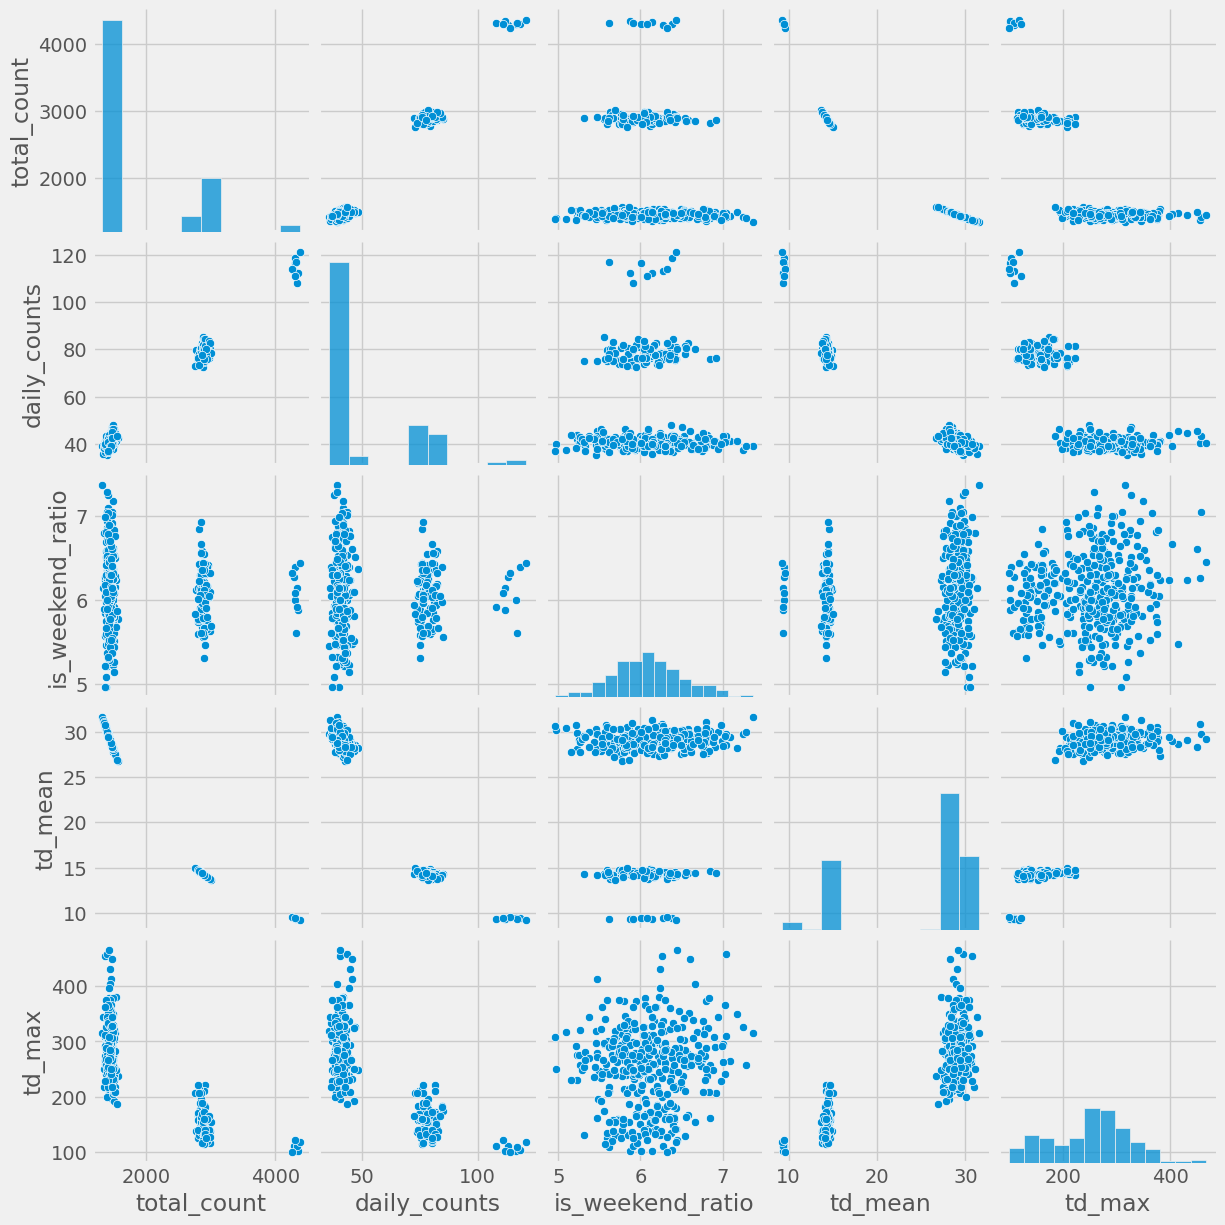

In [151]:
sns.pairplot(final_dataset[requi_feature_cols])

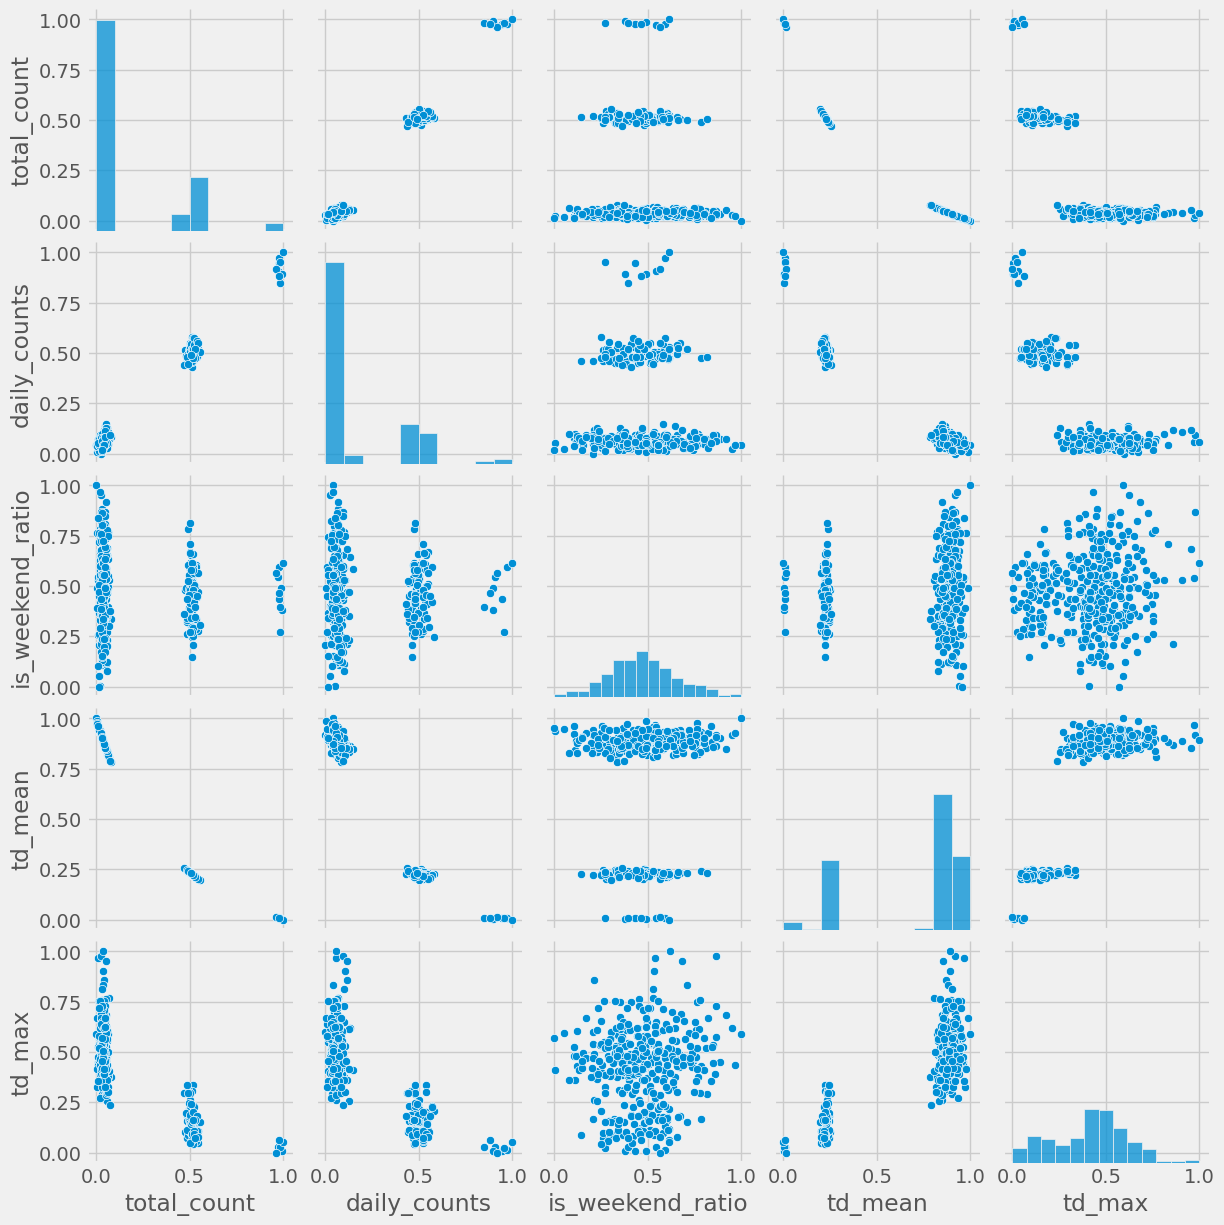

In [152]:
sns.pairplot(new_data)

In [153]:
cluster_num = range(1,15)

In [154]:
kmeans = [KMeans(n_clusters=i, random_state=RANDOM_STATE).fit(new_data) for i in cluster_num]

In [155]:
kmeans

[KMeans(n_clusters=1, random_state=30),
 KMeans(n_clusters=2, random_state=30),
 KMeans(n_clusters=3, random_state=30),
 KMeans(n_clusters=4, random_state=30),
 KMeans(n_clusters=5, random_state=30),
 KMeans(n_clusters=6, random_state=30),
 KMeans(n_clusters=7, random_state=30),
 KMeans(random_state=30),
 KMeans(n_clusters=9, random_state=30),
 KMeans(n_clusters=10, random_state=30),
 KMeans(n_clusters=11, random_state=30),
 KMeans(n_clusters=12, random_state=30),
 KMeans(n_clusters=13, random_state=30),
 KMeans(n_clusters=14, random_state=30)]

In [156]:
scores = [kmeans[i].score(new_data) for i in range(len(kmeans))]

In [157]:
scores

[-105.61717382018344,
 -22.662497940589933,
 -18.425259145173776,
 -11.341164011177803,
 -9.624264656308895,
 -7.683449116519145,
 -6.605626776063947,
 -5.773343216208606,
 -5.266967016355472,
 -4.7315422521940995,
 -4.483092839218672,
 -4.11097230945444,
 -3.9656970956213398,
 -3.8039099502550666]

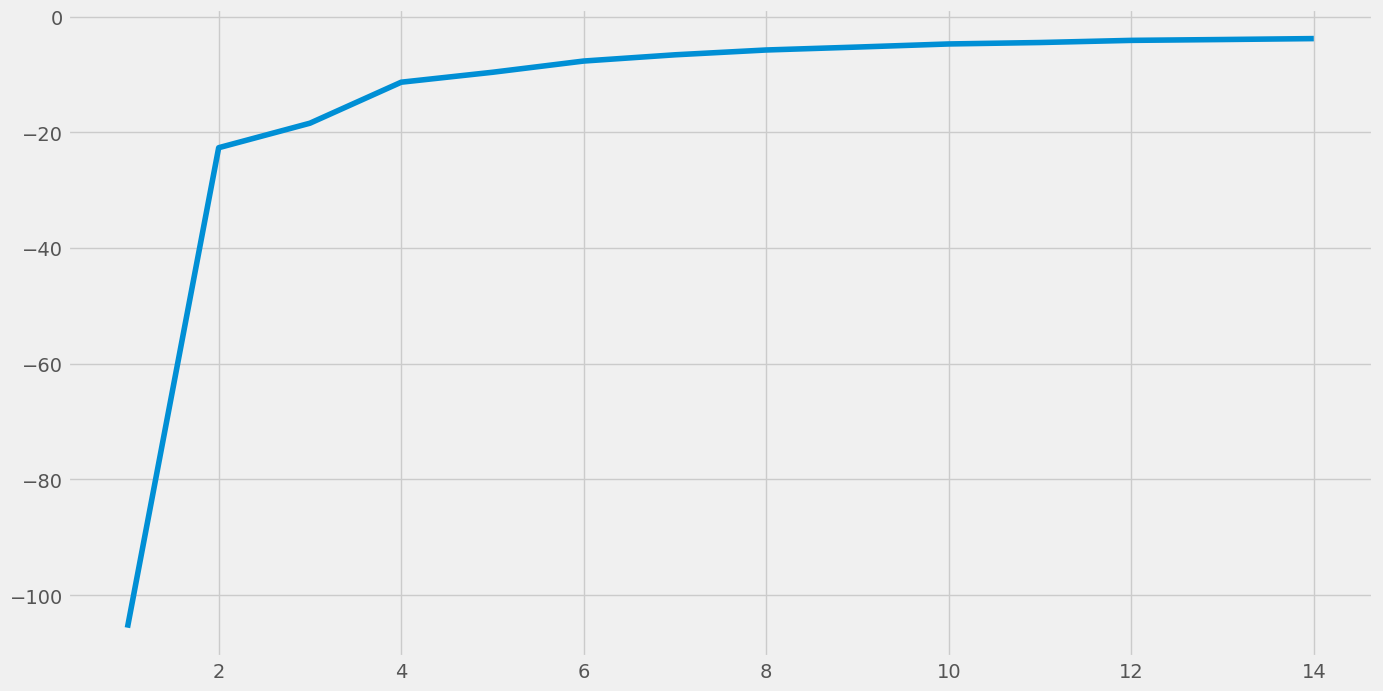

In [158]:
fig, sd = plt.subplots()
sd.plot(cluster_num,scores)
plt.show()

Displays the graph between no of clusters taken (i.e., 15) and scores calculate using kmeans

In [159]:
kmeans_cluster_model=kmeans[5]

In [160]:
kmeans_cluster_model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",30
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [161]:
final_dataset['cluster'] = kmeans_cluster_model.predict(new_data)
final_dataset['cluster'].value_counts()

cluster
4    99
2    94
3    73
0    60
5    50
1    10
Name: count, dtype: int64

# Clustering model with TSNE

t-Distributed Stochastic Neighbor Embedding (t-SNE)

In [162]:
from sklearn.manifold import TSNE

In [163]:
tsne = TSNE(n_components=2, verbose=1, perplexity=40,  random_state=RANDOM_STATE)

In [164]:
tsne_result = tsne.fit_transform(new_data)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 386 samples in 0.001s...
[t-SNE] Computed neighbors for 386 samples in 0.009s...
[t-SNE] Computed conditional probabilities for sample 386 / 386
[t-SNE] Mean sigma: 0.081652
[t-SNE] KL divergence after 250 iterations with early exaggeration: 48.032459
[t-SNE] KL divergence after 1000 iterations: 0.259716


In [165]:
tsne_result

array([[ 1.40193491e+01, -4.36342812e+00],
       [-3.61512451e+01,  6.15126419e+00],
       [ 3.84539986e+00,  3.56671739e+00],
       [ 4.08717155e+00, -1.18190680e+01],
       [ 4.10988235e+00, -7.08032322e+00],
       [ 2.91728616e-01, -3.77299833e+00],
       [ 3.93670797e+00, -1.08380661e+01],
       [ 1.29275494e+01,  6.28408146e+00],
       [ 8.32775116e-01, -1.76492846e+00],
       [-5.44636175e-02, -1.27737961e+01],
       [ 9.35681534e+00, -7.24679565e+00],
       [ 3.27656007e+00, -8.78959465e+00],
       [ 4.98964024e+00,  4.73359197e-01],
       [ 1.38911953e+01,  6.78393650e+00],
       [ 2.93147969e+00, -1.14980631e+01],
       [-2.89650860e+01,  9.53920650e+00],
       [ 1.58140111e+00, -2.59777594e+00],
       [ 1.25505018e+01,  4.75719452e+00],
       [-3.78120842e+01,  9.21754932e+00],
       [-3.74372900e-01, -1.08410227e+00],
       [-3.57608223e+01,  9.36401558e+00],
       [ 7.19037867e+00,  6.34324265e+00],
       [-3.56947784e+01,  6.91252708e+00],
       [ 1.

In [166]:
final_dataset['tsne-2d-one'] = tsne_result[:,0]
final_dataset['tsne-2d-two'] = tsne_result[:,1]

In [167]:
tsne_cluster = final_dataset.groupby('cluster').agg({'tsne-2d-one':'mean','tsne-2d-two':'mean'}).reset_index()

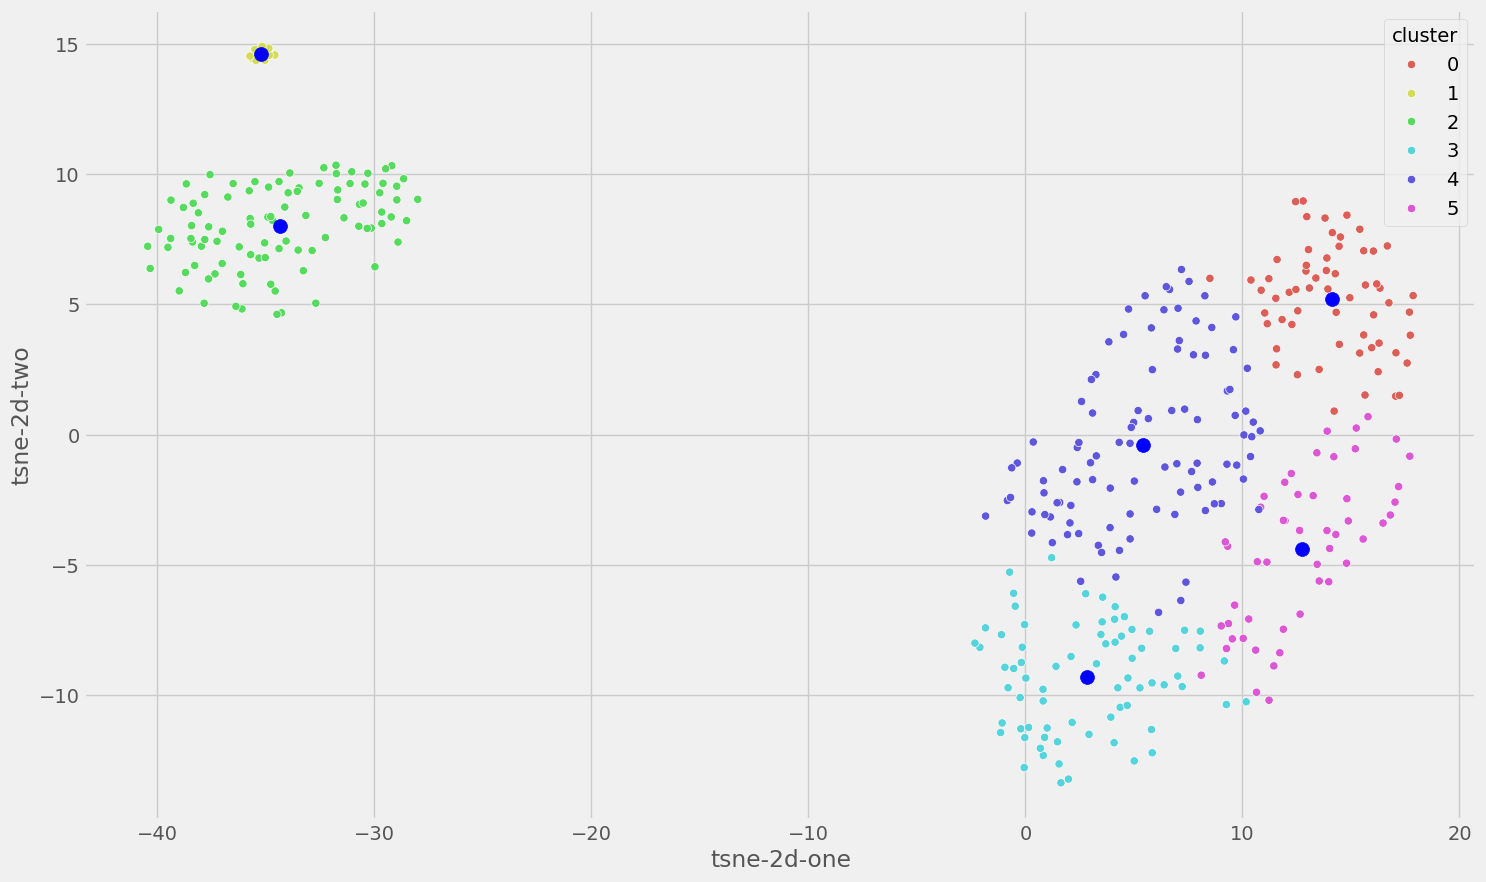

In [168]:
plt.figure(figsize=(16,10))

sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="cluster",
    palette=sns.color_palette("hls", 6),
    data=final_dataset,
    legend="full",
    alpha=1
)

plt.scatter(x="tsne-2d-one", y="tsne-2d-two", data=tsne_cluster, s=100, c='b')

plt.show()

In [169]:
centers = kmeans_cluster_model.cluster_centers_

In [170]:
pts = np.asarray(new_data)

In [171]:
pts

array([[0.03813281, 0.05263158, 0.51209855, 0.88495446, 0.71662125],
       [0.50295858, 0.49707602, 0.51626613, 0.23136629, 0.23433243],
       [0.0443787 , 0.05263158, 0.49222476, 0.86347879, 0.30517711],
       ...,
       [0.51742275, 0.47368421, 0.57788924, 0.22188316, 0.16348774],
       [0.50558843, 0.49122807, 0.57870081, 0.2304837 , 0.24250681],
       [0.03057199, 0.01754386, 0.14970523, 0.90324786, 0.45776567]],
      shape=(386, 5))

In [172]:
total_dist = pd.Series()

In [173]:
def get_sum_square_distance(data, kmeans_cluster_model):
    centers = kmeans_cluster_model.cluster_centers_
    pts = np.asarray(data[requi_feature_cols])
    
    total_dist = []

    for i in range(len(pts)):
        dist = 0
        for j in range(len(centers)):
            a = np.linalg.norm(pts[i] - centers[j])
            dist += a**2
        total_dist.append(dist)

    return pd.Series(total_dist)

In [174]:
final_dataset['sum_squa_dist'] = get_sum_square_distance(new_data, kmeans_cluster_model)

(array([ 6.,  7., 18., 23., 25., 44., 26., 23., 17., 20., 11., 21., 17.,
        25., 14., 15., 14., 11.,  7., 10.,  4.,  4.,  4.,  2.,  2.,  1.,
         1.,  0.,  0.,  0.,  0.,  3.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  2.,  0.,
         1.,  0.,  1.,  0.,  1.,  1.,  0.,  0.,  1.]),
 array([ 3.39616405,  3.48347384,  3.57078364,  3.65809343,  3.74540322,
         3.83271302,  3.92002281,  4.0073326 ,  4.09464239,  4.18195219,
         4.26926198,  4.35657177,  4.44388157,  4.53119136,  4.61850115,
         4.70581095,  4.79312074,  4.88043053,  4.96774032,  5.05505012,
         5.14235991,  5.2296697 ,  5.3169795 ,  5.40428929,  5.49159908,
         5.57890887,  5.66621867,  5.75352846,  5.84083825,  5.928148

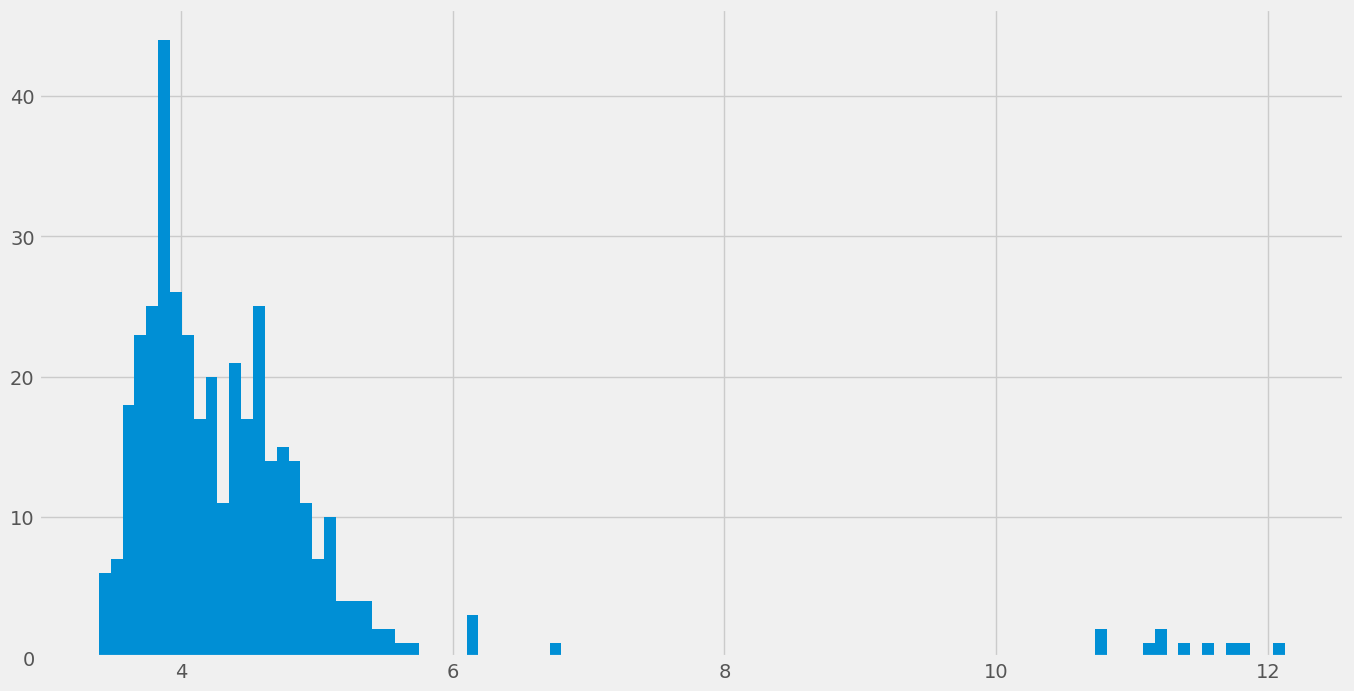

In [175]:
plt.hist(final_dataset['sum_squa_dist'], bins=100)

In [176]:
cutoff = 6

In [177]:
final_dataset['anomaly_kmeans'] = (final_dataset['sum_squa_dist'] >= cutoff).astype(int)

<Axes: xlabel='tsne-2d-one', ylabel='tsne-2d-two'>

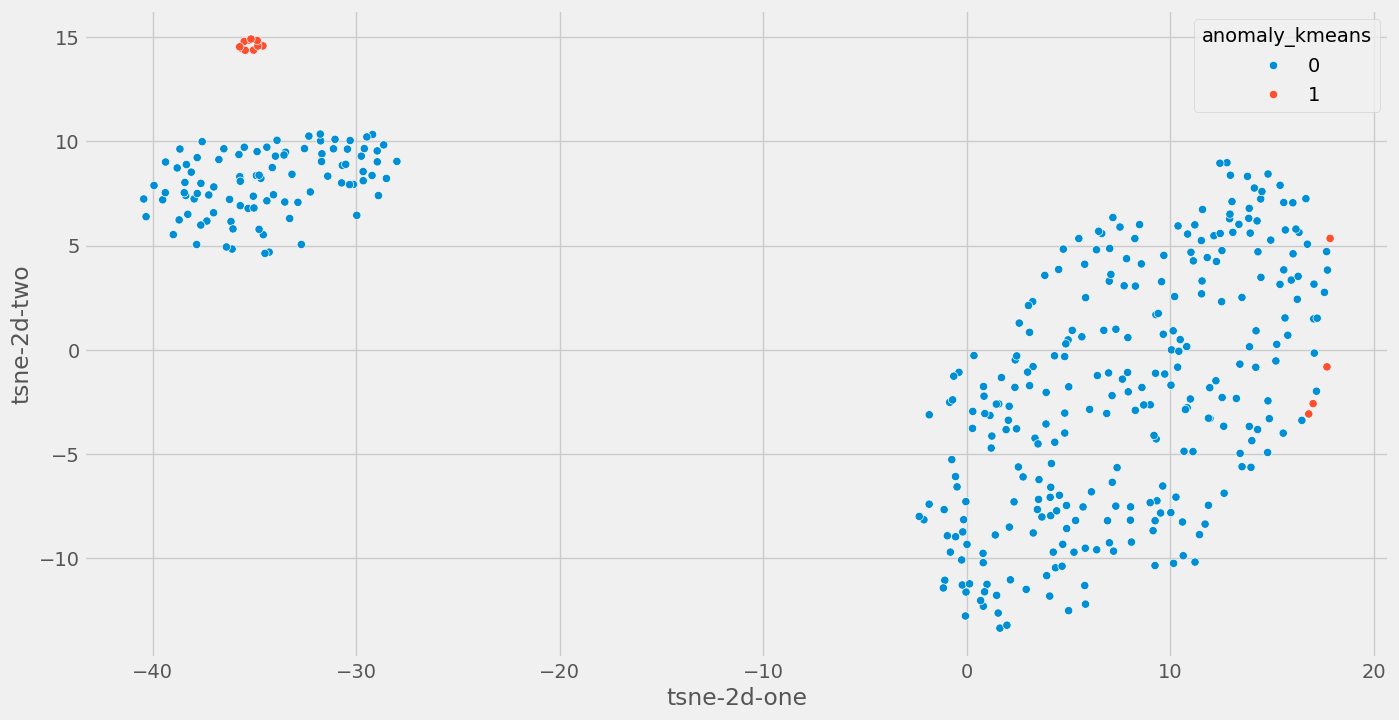

In [178]:
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="anomaly_kmeans",
    data=final_dataset,
    legend="full",
    alpha=1
)

In [179]:
final_dataset.loc[final_dataset['anomaly_kmeans']==1]

,ip_address,total_count,daily_counts,is_weekend_ratio,td_mean,td_max,cluster,tsne-2d-one,tsne-2d-two,sum_squa_dist,anomaly_kmeans
42,10.1.1.199,1365,40.5,6.260638,30.801320,455.0,5,16.815884,-3.080763,6.132820,1
62,10.1.1.249,4301,116.5,6.004886,9.459535,101.0,1,-35.040981,14.375975,11.536764,1
118,10.1.1.386,4300,118.5,6.388316,9.453361,104.0,1,-35.618992,14.442822,11.746609,1
163,10.1.1.483,1330,39.0,7.364780,31.564334,316.0,0,17.865923,5.340898,6.141373,1
164,10.1.1.486,4317,117.0,5.611026,9.417285,108.0,1,-34.581497,14.576503,11.819613,1
177,10.1.1.63,4339,112.0,6.136513,9.368142,101.0,1,-35.256508,14.848812,11.251859,1
188,10.1.1.86,4293,113.0,6.276271,9.456897,110.0,1,-35.502846,14.788448,11.096376,1
255,10.1.2.249,4353,112.0,5.876777,9.332721,102.0,1,-34.834442,14.571095,11.356003,1
286,10.1.2.323,1408,43.5,7.045714,29.719261,458.0,5,17.712061,-0.821845,6.742907,1
311,10.1.2.386,4326,108.0,5.910543,9.392370,110.0,1,-34.858768,14.833764,10.814194,1


# Isolated Forest

In [180]:
from sklearn.ensemble import IsolationForest

In [181]:
outlier_frac = 0.028

In [182]:
final_dataset.columns

Index(['ip_address', 'total_count', 'daily_counts', 'is_weekend_ratio',
       'td_mean', 'td_max', 'cluster', 'tsne-2d-one', 'tsne-2d-two',
       'sum_squa_dist', 'anomaly_kmeans'],
      dtype='str')

In [183]:
new_data.head()

,total_count,daily_counts,is_weekend_ratio,td_mean,td_max
0,0.038133,0.052632,0.512099,0.884954,0.716621
1,0.502959,0.497076,0.516266,0.231366,0.234332
2,0.044379,0.052632,0.492225,0.863479,0.305177
3,0.025641,0.000000,0.205662,0.919573,0.599455
4,0.042406,0.081871,0.342074,0.872065,0.487738


In [184]:
iso_model =  IsolationForest(n_jobs=-1, n_estimators=200, max_features=3, random_state=RANDOM_STATE, contamination=outlier_frac)

In [185]:
iso_model.fit(new_data)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.028
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",3
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",30
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [186]:
final_dataset['anomaly_isolated'] = pd.Series(iso_model.predict(new_data))

In [187]:
final_dataset['anomaly_isolated'] = final_dataset['anomaly_isolated'].map( {1: 0, -1: 1} )

In [188]:
final_dataset['anomaly_isolated'].value_counts()

anomaly_isolated
0    375
1     11
Name: count, dtype: int64

<Axes: xlabel='tsne-2d-one', ylabel='tsne-2d-two'>

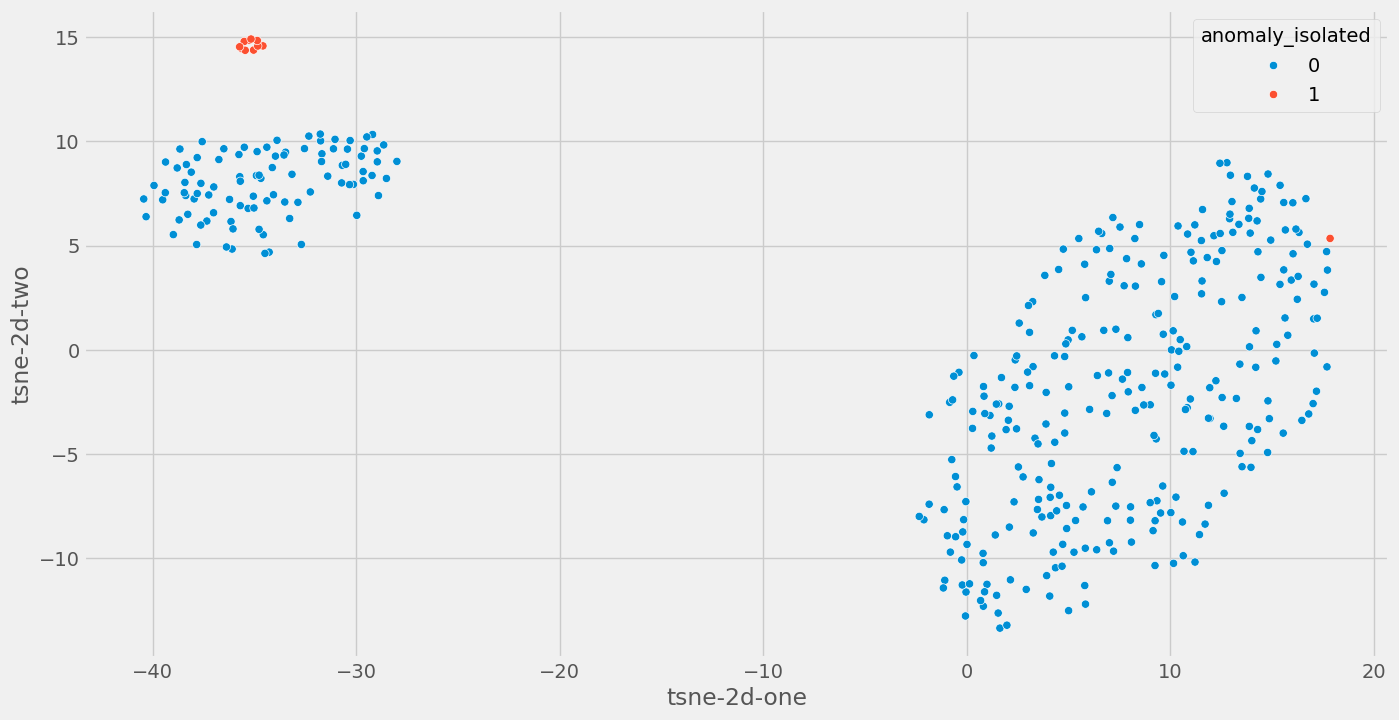

In [189]:
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="anomaly_isolated",
    data=final_dataset,
    legend="full",
    alpha=1
)

In [190]:
final_dataset.loc[final_dataset['anomaly_isolated']==1]

,ip_address,total_count,daily_counts,is_weekend_ratio,td_mean,td_max,cluster,tsne-2d-one,tsne-2d-two,sum_squa_dist,anomaly_kmeans,anomaly_isolated
62,10.1.1.249,4301,116.5,6.004886,9.459535,101.0,1,-35.040981,14.375975,11.536764,1,1
118,10.1.1.386,4300,118.5,6.388316,9.453361,104.0,1,-35.618992,14.442822,11.746609,1,1
163,10.1.1.483,1330,39.0,7.364780,31.564334,316.0,0,17.865923,5.340898,6.141373,1,1
164,10.1.1.486,4317,117.0,5.611026,9.417285,108.0,1,-34.581497,14.576503,11.819613,1,1
177,10.1.1.63,4339,112.0,6.136513,9.368142,101.0,1,-35.256508,14.848812,11.251859,1,1
188,10.1.1.86,4293,113.0,6.276271,9.456897,110.0,1,-35.502846,14.788448,11.096376,1,1
255,10.1.2.249,4353,112.0,5.876777,9.332721,102.0,1,-34.834442,14.571095,11.356003,1,1
311,10.1.2.386,4326,108.0,5.910543,9.392370,110.0,1,-34.858768,14.833764,10.814194,1,1
357,10.1.2.486,4251,114.0,6.316695,9.571059,99.0,1,-35.453377,14.365527,11.179807,1,1
370,10.1.2.63,4372,121.0,6.435374,9.268588,118.0,1,-35.726658,14.533191,12.127143,1,1


# One Class SVM

In [191]:
from sklearn.svm import OneClassSVM

In [192]:
svm_model =  OneClassSVM(nu=outlier_frac, degree=2, kernel='rbf')

In [193]:
new_data_clean = new_data.loc[new_data.total_count <=new_data.total_count.quantile(1-outlier_frac)]

In [194]:
svm_model.fit(new_data_clean)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.028
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [195]:
final_dataset['anomaly_svm'] = pd.Series(svm_model.predict(new_data))

In [196]:
final_dataset['anomaly_svm'] = final_dataset['anomaly_svm'].map( {1: 0, -1: 1} )

In [197]:
final_dataset['anomaly_svm'].value_counts()

anomaly_svm
0    367
1     19
Name: count, dtype: int64

<Axes: xlabel='tsne-2d-one', ylabel='tsne-2d-two'>

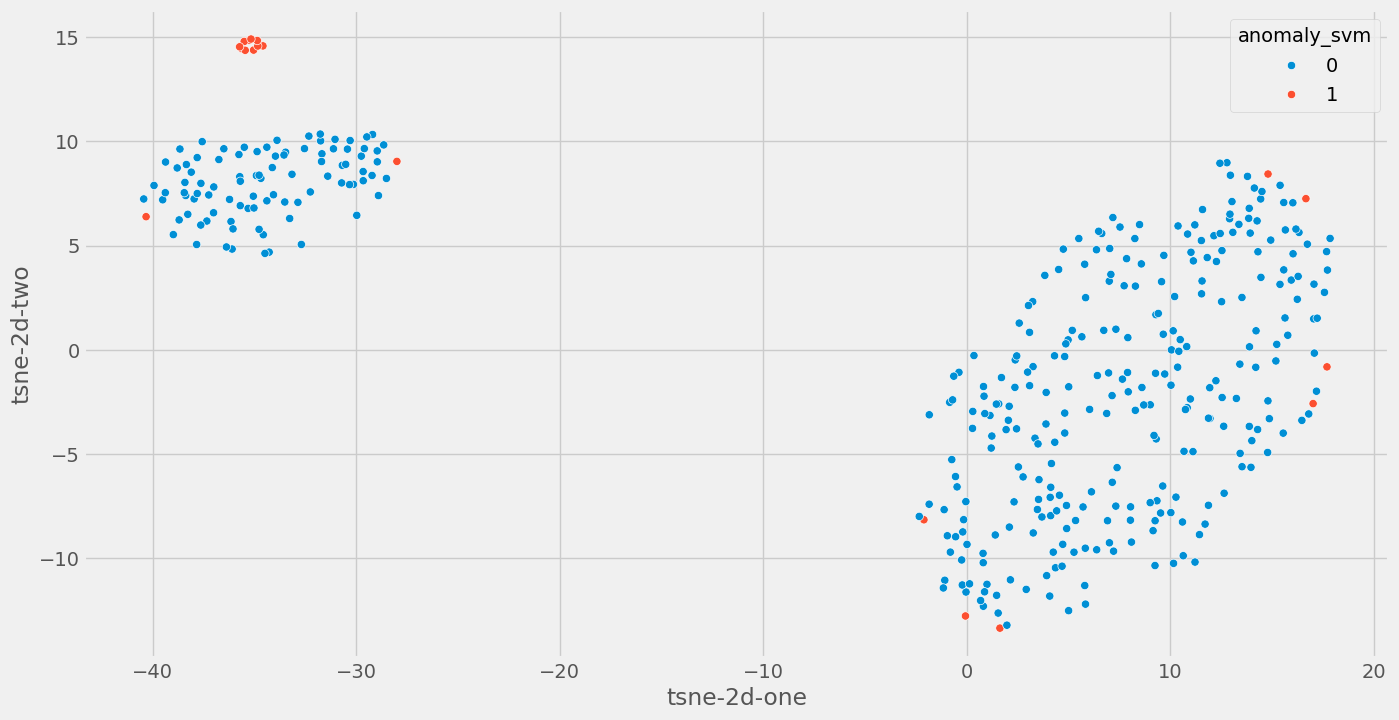

In [198]:
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="anomaly_svm",
    data=final_dataset,
    legend="full",
    alpha=1
)

In [199]:
final_dataset.loc[final_dataset['anomaly_svm']==1]

,ip_address,total_count,daily_counts,is_weekend_ratio,td_mean,td_max,cluster,tsne-2d-one,tsne-2d-two,sum_squa_dist,anomaly_kmeans,anomaly_isolated,anomaly_svm
9,10.1.1.12,1392,40.0,4.974249,30.152408,250.0,3,-0.054464,-12.773796,5.321517,0,0,1
37,10.1.1.186,1372,37.0,4.965217,30.557987,308.0,3,1.638033,-13.356425,5.735236,0,0,1
62,10.1.1.249,4301,116.5,6.004886,9.459535,101.0,1,-35.040981,14.375975,11.536764,1,1,1
118,10.1.1.386,4300,118.5,6.388316,9.453361,104.0,1,-35.618992,14.442822,11.746609,1,1,1
164,10.1.1.486,4317,117.0,5.611026,9.417285,108.0,1,-34.581497,14.576503,11.819613,1,1,1
177,10.1.1.63,4339,112.0,6.136513,9.368142,101.0,1,-35.256508,14.848812,11.251859,1,1,1
183,10.1.1.73,1484,40.5,5.480349,28.191504,195.0,3,-2.096231,-8.158484,4.080323,0,0,1
188,10.1.1.86,4293,113.0,6.276271,9.456897,110.0,1,-35.502846,14.788448,11.096376,1,1,1
225,10.1.2.178,1400,39.0,7.284024,29.964975,258.0,0,16.676750,7.247638,5.337704,0,0,1
233,10.1.2.195,2859,76.5,6.919668,14.448915,206.0,2,-40.324463,6.383013,4.898477,0,0,1


# Performance of the Algorithm

We must manually categorise the data and examine the performance of the individual algos because it is unsupervised.

In [200]:
total_counts_condition = (final_dataset['total_count'] >= final_dataset['total_count'].quantile(0.90)) 
daily_counts_condition =  (final_dataset['daily_counts'] >= final_dataset['daily_counts'].quantile(0.90))

In [201]:
final_dataset['anomaly_manual'] = (total_counts_condition | daily_counts_condition).astype(int)

In [202]:
final_dataset.head()

,ip_address,total_count,daily_counts,is_weekend_ratio,td_mean,td_max,cluster,tsne-2d-one,tsne-2d-two,sum_squa_dist,anomaly_kmeans,anomaly_isolated,anomaly_svm,anomaly_manual
0,10.1.1.1,1446,40.0,6.194030,28.999308,362.0,5,14.019349,-4.363428,4.373527,0,0,0,0
1,10.1.1.100,2860,78.0,6.204030,14.427072,185.0,2,-36.151245,6.151264,4.382788,0,0,0,0
2,10.1.1.101,1465,40.0,6.146341,28.520492,211.0,4,3.845400,3.566717,3.665171,0,0,0,0
3,10.1.1.106,1408,35.5,5.458716,29.771144,319.0,3,4.087172,-11.819068,4.756890,0,0,0,0
4,10.1.1.109,1459,42.5,5.786047,28.711934,278.0,3,4.109882,-7.080323,3.767847,0,0,0,0


In [203]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, confusion_matrix

In [204]:
def get_sensitivity_specificity(y_true, y_pred):
    cf = confusion_matrix(y_true, y_pred)
    sensitivity = cf[0,0]/(cf[:,0].sum())
    specificity = cf[1,1]/(cf[:,1].sum())
    return sensitivity, specificity

In [205]:
f1_iso = f1_score(final_dataset['anomaly_manual'],final_dataset['anomaly_isolated'])
acc_iso = accuracy_score(final_dataset['anomaly_manual'],final_dataset['anomaly_isolated'])
roc_iso = roc_auc_score(final_dataset['anomaly_manual'],final_dataset['anomaly_isolated'])
sen_iso, spec_iso = get_sensitivity_specificity(final_dataset['anomaly_manual'],final_dataset['anomaly_isolated'])
met_iso = {
           'f1_score': f1_iso,
           'accuracy': acc_iso,
           'roc_score': roc_iso,
           'sensitivity': sen_iso,
           'specificity': spec_iso
          }

In [206]:
f1_kmeans = f1_score(final_dataset['anomaly_manual'],final_dataset['anomaly_kmeans'])
acc_kmeans = accuracy_score(final_dataset['anomaly_manual'],final_dataset['anomaly_kmeans'])
roc_kmeans = roc_auc_score(final_dataset['anomaly_manual'],final_dataset['anomaly_kmeans'])
sen_kmeans, spec_kmeans = get_sensitivity_specificity(final_dataset['anomaly_manual'],final_dataset['anomaly_kmeans'])
met_kmeans = {
           'f1_score': f1_kmeans,
           'accuracy': acc_kmeans,
           'roc_score': roc_kmeans,
           'sensitivity': sen_kmeans,
           'specificity': spec_kmeans
          }

In [207]:
f1_svm = f1_score(final_dataset['anomaly_manual'],final_dataset['anomaly_svm'])
acc_svm = accuracy_score(final_dataset['anomaly_manual'],final_dataset['anomaly_svm'])
roc_svm = roc_auc_score(final_dataset['anomaly_manual'],final_dataset['anomaly_svm'])
sen_svm, spec_svm = get_sensitivity_specificity(final_dataset['anomaly_manual'],final_dataset['anomaly_svm'])
met_svm = {
           'f1_score': f1_svm,
           'accuracy': acc_svm,
           'roc_score': roc_svm,
           'sensitivity': sen_svm,
           'specificity': spec_svm
          }

In [208]:
metrics = {'isolated_forest': met_iso,
           'kmeans': met_kmeans,
           'svm': met_svm
          }

In [209]:
all_metrics = pd.DataFrame.from_dict(metrics)

In [210]:
all_metrics

,isolated_forest,kmeans,svm
f1_score,0.303030,0.289855,0.270270
accuracy,0.880829,0.873057,0.860104
roc_score,0.589399,0.584867,0.577314
sensitivity,0.880000,0.879032,0.877384
specificity,0.909091,0.714286,0.526316


# Ensemble models for Classification

In [211]:
from sklearn.preprocessing import LabelEncoder
final_dataset['ip_address'] = LabelEncoder().fit_transform(final_dataset.iloc[:, -1])

In [212]:
features = ['ip_address', 'total_count', 'daily_counts', 'is_weekend_ratio', 'td_mean', 'td_max']
X = final_dataset[features]
y = final_dataset['anomaly_isolated']

In [222]:
X

,ip_address,total_count,daily_counts,is_weekend_ratio,td_mean,td_max
0,0,1446,40.0,6.194030,28.999308,362.0
1,0,2860,78.0,6.204030,14.427072,185.0
2,0,1465,40.0,6.146341,28.520492,211.0
3,0,1408,35.5,5.458716,29.771144,319.0
4,0,1459,42.5,5.786047,28.711934,278.0
...,...,...,...,...,...,...
381,1,4307,111.0,6.083882,9.441013,122.0
382,0,2826,73.5,6.227621,14.612743,207.0
383,1,2904,76.0,6.351899,14.215639,159.0
384,0,2868,77.5,6.353846,14.407394,188.0


In [213]:
X, y = final_dataset[features], final_dataset['anomaly_isolated']
X.shape, y.shape

((386, 6), (386,))

## Baseline Classifier

In [214]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold

rf = OneVsRestClassifier(estimator = GaussianNB())

# Create RepeatedStratifiedKFold cross-validator with 10 folds, 3 repeats and a seed of 1.
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=20)

# Calculating accuracy using `cross_val_score()` with model instantiated, data to fit, 
# target variable, 'accuracy' scoring, cross validator, n_jobs=-1, and error_score set to 'raise'
n_scores = cross_val_score(rf, X, y, scoring='f1_weighted', cv=cv, error_score='raise')

# Print mean and standard deviation of n_scores: 
print(n_scores)
print('Baseline scores \n mean f1 weighted: %.3f with a %.3f standard deviation in scores ' % (np.mean(n_scores), np.std(n_scores)))

[0.91306815 0.92877493 0.86485671 0.94457323 0.96084546 0.95655271
 0.96070175 0.91064618 0.91064618 0.87780396 0.92877493 0.83100233
 0.94457323 0.91306815 0.92877493 0.95655271 0.94306894 0.87780396
 0.94306894 0.96070175 0.96084546 0.91306815 0.91306815 0.89725275
 0.91306815 0.86824618 0.89434985 1.         0.94306894 0.96070175]
Baseline scores 
 mean f1 weighted: 0.924 with a 0.036 standard deviation in scores 


## Stacking Classifier

Stacking classifier takes:
1. estimators: List of baseline classifiers

2. final_estimator: Defined meta classifier

3. cv: Number of cross validations to perform

In [215]:
def create_stacking_models():
    base_models = list()
    base_models.append(('KNNC', KNeighborsClassifier(n_neighbors = len(np.unique(y))
                                                     , weights = 'distance')
                       ))
    base_models.append(('SVC', SVC(kernel = 'linear'
                                   , class_weight = 'balanced'
                                  , break_ties = True)
                       ))    
    base_models.append(('GNB', GaussianNB()))
    base_models.append(('RF', RandomForestClassifier(n_estimators= 200, 
                                                   oob_score = True, 
                                                   class_weight = "balanced", 
                                                   random_state = 20, 
                                                   ccp_alpha = 0.1)
                       ))

    
    meta_model = LogisticRegression()
    final_model = StackingClassifier(estimators = base_models, ##Base estimators which will be stacked together
                                     final_estimator = meta_model,
                                     cv = 5
                                    )
    return final_model

def models_all():
    all_models = dict()
    all_models['KNNC']= KNeighborsClassifier(n_neighbors = len(np.unique(y))
                                             , weights = 'distance')
    all_models['SVC']= SVC(kernel = 'linear'
                           , class_weight = 'balanced'
                          , break_ties = True
                          )
    all_models['RF']= RandomForestClassifier(n_estimators= 200, 
                                                   oob_score = True, 
                                                   class_weight = "balanced", 
                                                   random_state = 20, 
                                                   ccp_alpha = 0.15)
    all_models['GNB'] = GaussianNB()
    all_models['Stacking'] = create_stacking_models()
    return all_models

def evaluate_model(model):
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
    scores = cross_val_score(model, X, y, scoring='f1_weighted', cv=cv, error_score='raise')
    return scores

In [216]:
model_results = list()
models = models_all()
names = list()

# Creating a for loop that iterates over each name, model in models dictionary 
for name, model in models.items():
    scores = evaluate_model(model)
    model_results.append(scores)
    names.append(name)
#   print(model_results)
    print('>%s %.3f (%.3f) \n' % (name, np.mean(scores), np.std(scores)))

>KNNC 0.994 (0.012) 

>SVC 0.996 (0.011) 

>RF 0.996 (0.011) 

>GNB 0.921 (0.035) 

>Stacking 0.996 (0.011) 



In [217]:
y = final_dataset['anomaly_isolated']

In [218]:
final_model = create_stacking_models()
final_model.fit(X, y)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('KNNC', ...), ('SVC', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary."

In [219]:
from sklearn.metrics import accuracy_score

y_pred = final_model.predict(X)

accuracy = accuracy_score(y, y_pred)

print("Training Accuracy:", accuracy)

Training Accuracy: 1.0


In [220]:
import pickle

# Save model
with open("anomaly_detection_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(min_max_scaler, f)

In [221]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
final_dataset['ip_address'] = le.fit_transform(final_dataset['ip_address'])

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)